In [114]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import hanoi
from itables import show



Read data

In [117]:
d_L2 = pd.read_csv("data/L2_n1/L2_n1_step.txt", delimiter=" ")

In [118]:
d_L2.head()

,m0,m1,v0,v1,n_gen,allele_fixed_l0,allele_fixed_l1
0,0.0,0.0,0.01,0.01,1,NaN,NaN
1,0.0,0.0,0.01,0.01,1,NaN,NaN
2,0.0,0.0,0.01,0.01,1,NaN,NaN
3,0.0,0.0,0.01,0.01,1,NaN,NaN
4,0.0,0.0,0.01,0.01,1,NaN,NaN


In [120]:
d_L2.dropna(inplace=True)

In [129]:
d_L2_gb = d_L2.groupby(["m0", "m1", "v0", "v1"])

Extinction prob of locus 0.

In [134]:
d_L2_gb.agg(p_ext = ("allele_fixed_l0", lambda x: x.isna().sum()/x.size),
         p_fix_l0_1 = ("allele_fixed_l0", "mean"),
         p_fix_l1_1 = ("allele_fixed_l1", "mean")
        ).reset_index()

,m0,m1,v0,v1,p_ext,p_fix_l0_1,p_fix_l1_1
0,0.0,0.0,0.01,0.100000,0.0,1.000000,1.00
1,0.0,0.0,0.01,0.158489,0.0,1.000000,1.00
2,0.0,0.0,0.01,0.251189,0.0,0.951220,1.00
3,0.0,0.0,0.01,0.398107,0.0,0.845238,1.00
4,0.0,0.0,0.01,0.630957,0.0,0.830000,1.00
...,...,...,...,...,...,...,...
6371,2.0,2.0,10.00,1.584893,0.0,0.520000,1.00
6372,2.0,2.0,10.00,2.511886,0.0,0.580000,1.00
6373,2.0,2.0,10.00,3.981072,0.0,0.530000,1.00
6374,2.0,2.0,10.00,6.309573,0.0,0.540000,0.97


In [135]:
d_L2_1 = d_L2[d_L2["allele_fixed_l0"] == 1].groupby(["m0", "m1", "v0", "v1"])

In [136]:
d_L2_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

,m0,m1,v0,v1,t_fix_1
0,0.0,0.0,0.01,0.100000,1.000000
1,0.0,0.0,0.01,0.158489,1.000000
2,0.0,0.0,0.01,0.251189,1.487179
3,0.0,0.0,0.01,0.398107,4.098592
4,0.0,0.0,0.01,0.630957,12.012048
...,...,...,...,...,...
4062,2.0,2.0,10.00,1.584893,200.384615
4063,2.0,2.0,10.00,2.511886,190.793103
4064,2.0,2.0,10.00,3.981072,212.301887
4065,2.0,2.0,10.00,6.309573,195.925926


In [125]:
d_smr_L1 = pd.merge(
    d_L1_gb.agg(p_ext = ("allele_fixed_l0", lambda x: x.isna().sum()/x.size),
         p_fix_l0_1 = ("allele_fixed_l0", "mean"),
         p_fix_l1_1 = ("allele_fixed_l1", "mean")
        ).reset_index(),
    d_1.agg(t_fix = ("n_gen", "mean")).reset_index(),
    on = ["m0", "m1", "v0", "v1"],
    how = "left"
)

KeyError: "Column(s) ['allele_fixed_l0', 'allele_fixed_l1'] do not exist"

In [39]:
d_smr

,m0,m1,v0,v1,p_ext,p_fix_l0_1,p_fix_l1_1,t_fix
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,0.52,1.00,217.644068
6396,2.0,2.0,10.00,2.511886,0.0,0.58,1.00,218.290323
6397,2.0,2.0,10.00,3.981072,0.0,0.53,1.00,179.403846
6398,2.0,2.0,10.00,6.309573,0.0,0.54,0.97,211.745455


In [40]:
d_smr.shape

(6400, 8)

In [116]:
show(d_smr)

Loading ITables v2.7.0 from the internet... (need help?)


In [41]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [43]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, column, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values=column)
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [44]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [82]:
def heatmap_panel(data, values="p_fix_l1_1", vmin = 0, vmax = 1, cmap = "coolwarm", **kwargs):
    ax = plt.gca()
    
    # Pivot and plot
    table = data.pivot(index="v1", columns="v0", values=values)
    sns.heatmap(table, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.invert_yaxis()

    # Sparse tick labels (every 5th), formatted as powers of 10
    def power_of_10_label(series, tick_pos, step=5):
        labels = []
        for i, t in enumerate(tick_pos):
            if i % step == 0:
                val = series[int(t)]
                labels.append(f"$10^{{{int(np.log10(val))}}}$")
            else:
                labels.append("")
        return labels

    ax.set_xticklabels(power_of_10_label(table.columns, ax.get_xticks()), rotation=0)
    ax.set_yticklabels(power_of_10_label(table.index,   ax.get_yticks()))

    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)


def plot_facet_heatmap(data, row, col, row_order, col_order, values="p_fix_l1_1", cmap = "coolwarm", vmin = 0, vmax = 1, cbar_label="$p_{fix1}$"):
    g = sns.FacetGrid(data, row=row, col=col, row_order=row_order, col_order=col_order, margin_titles=True)
    g.map_dataframe(heatmap_panel, values=values, cmap = cmap, vmin = vmin, vmax = vmax)

    g.fig.supxlabel("v0", x=0.5, y=0)
    g.fig.supylabel("v1",  y=0.5, x=0)

    # Colorbar anchored to the last panel
    last_ax = g.axes[-1, -1]
    pos = last_ax.get_position()
    cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
    cbar.set_label(cbar_label, rotation=0, labelpad=10, va='center', ha='left')

    plt.show()
    return g

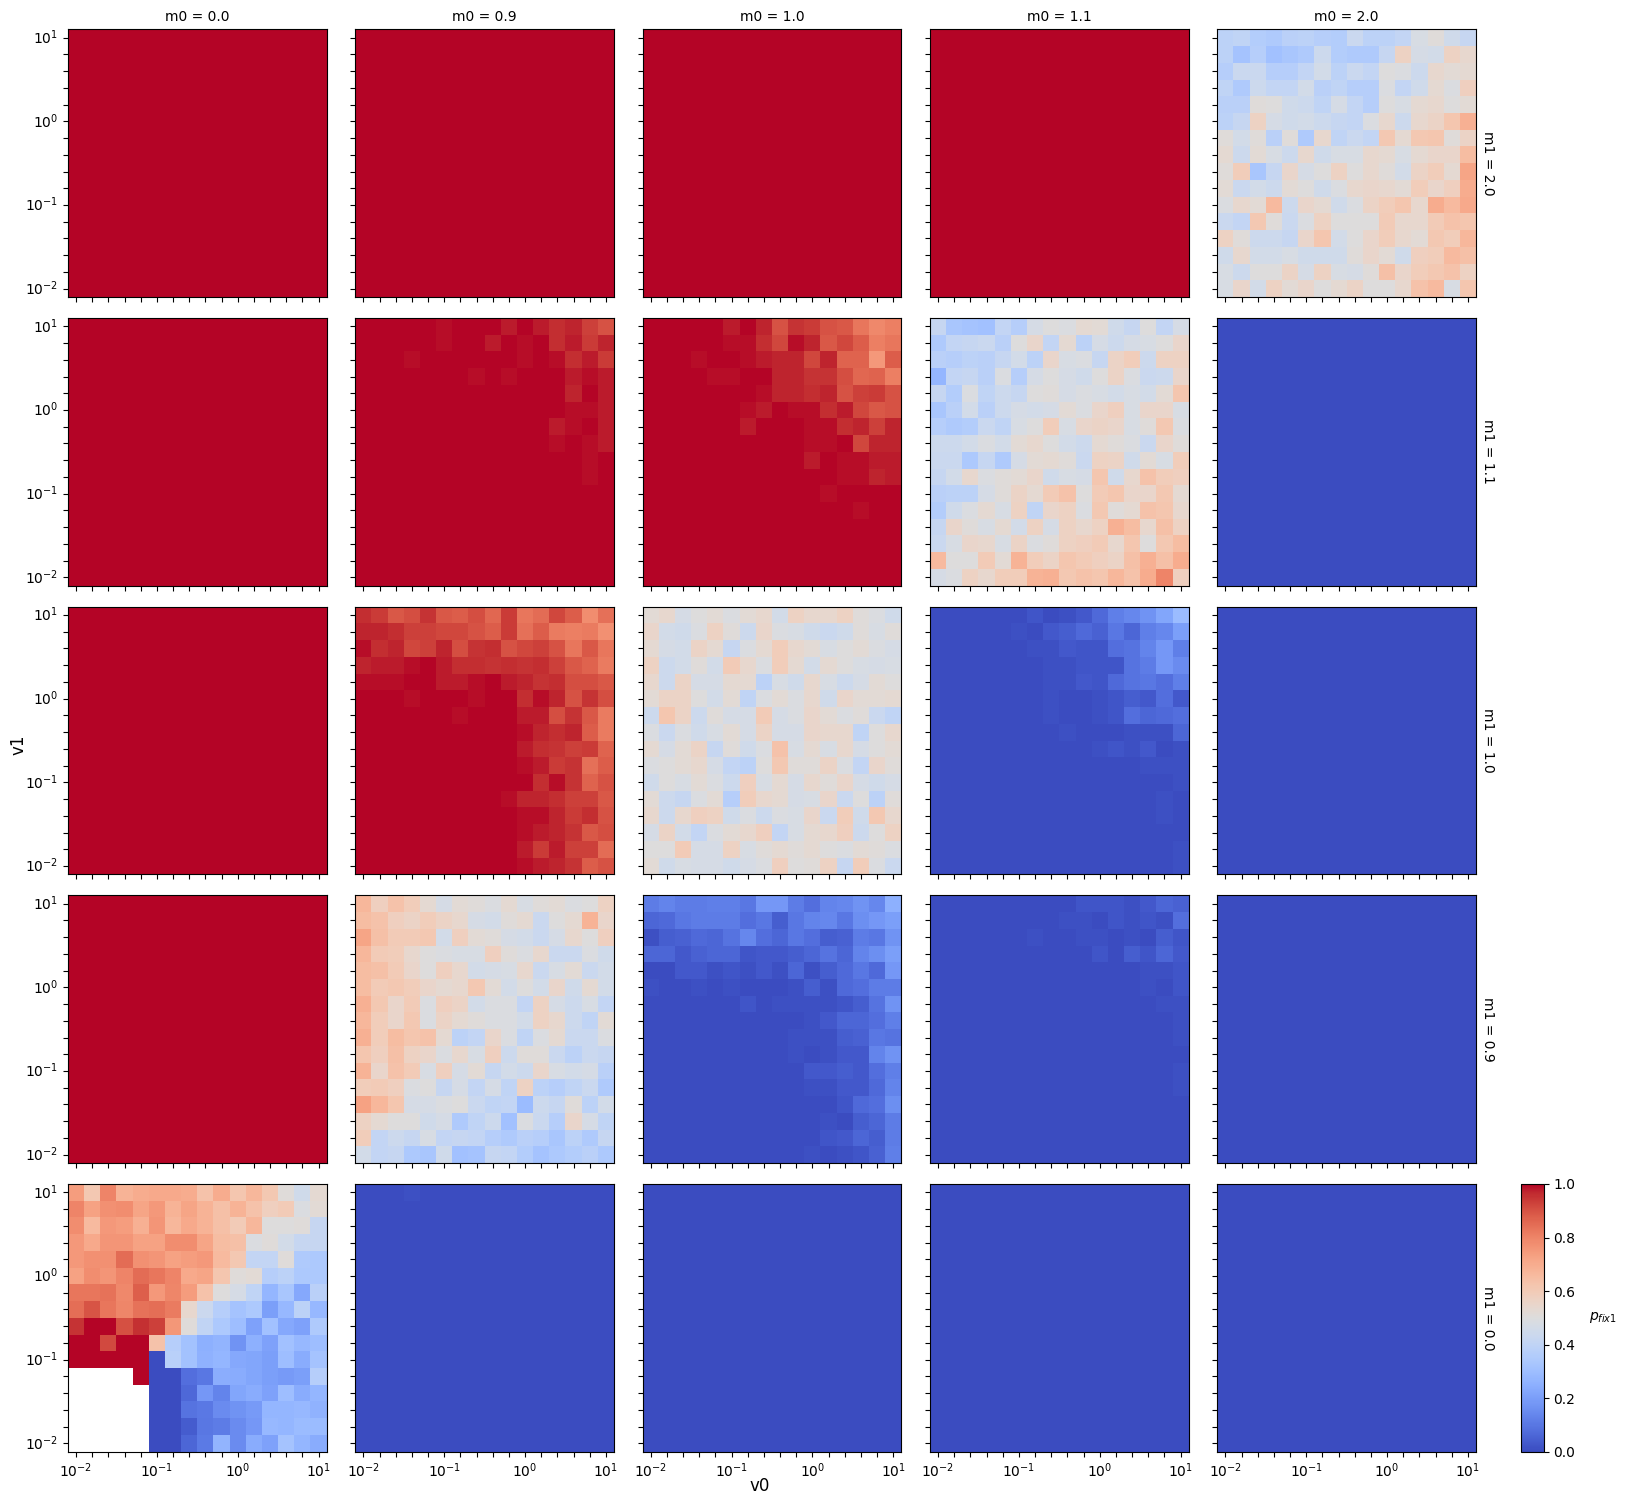

In [83]:
g_0 = plot_facet_heatmap(
    data=d_smr,
    row="m1", col="m0",
    row_order=row_order_m, col_order=col_order_m,
    values="p_fix_l0_1",       # ← change this easily
    cbar_label="$p_{fix1}$"
)

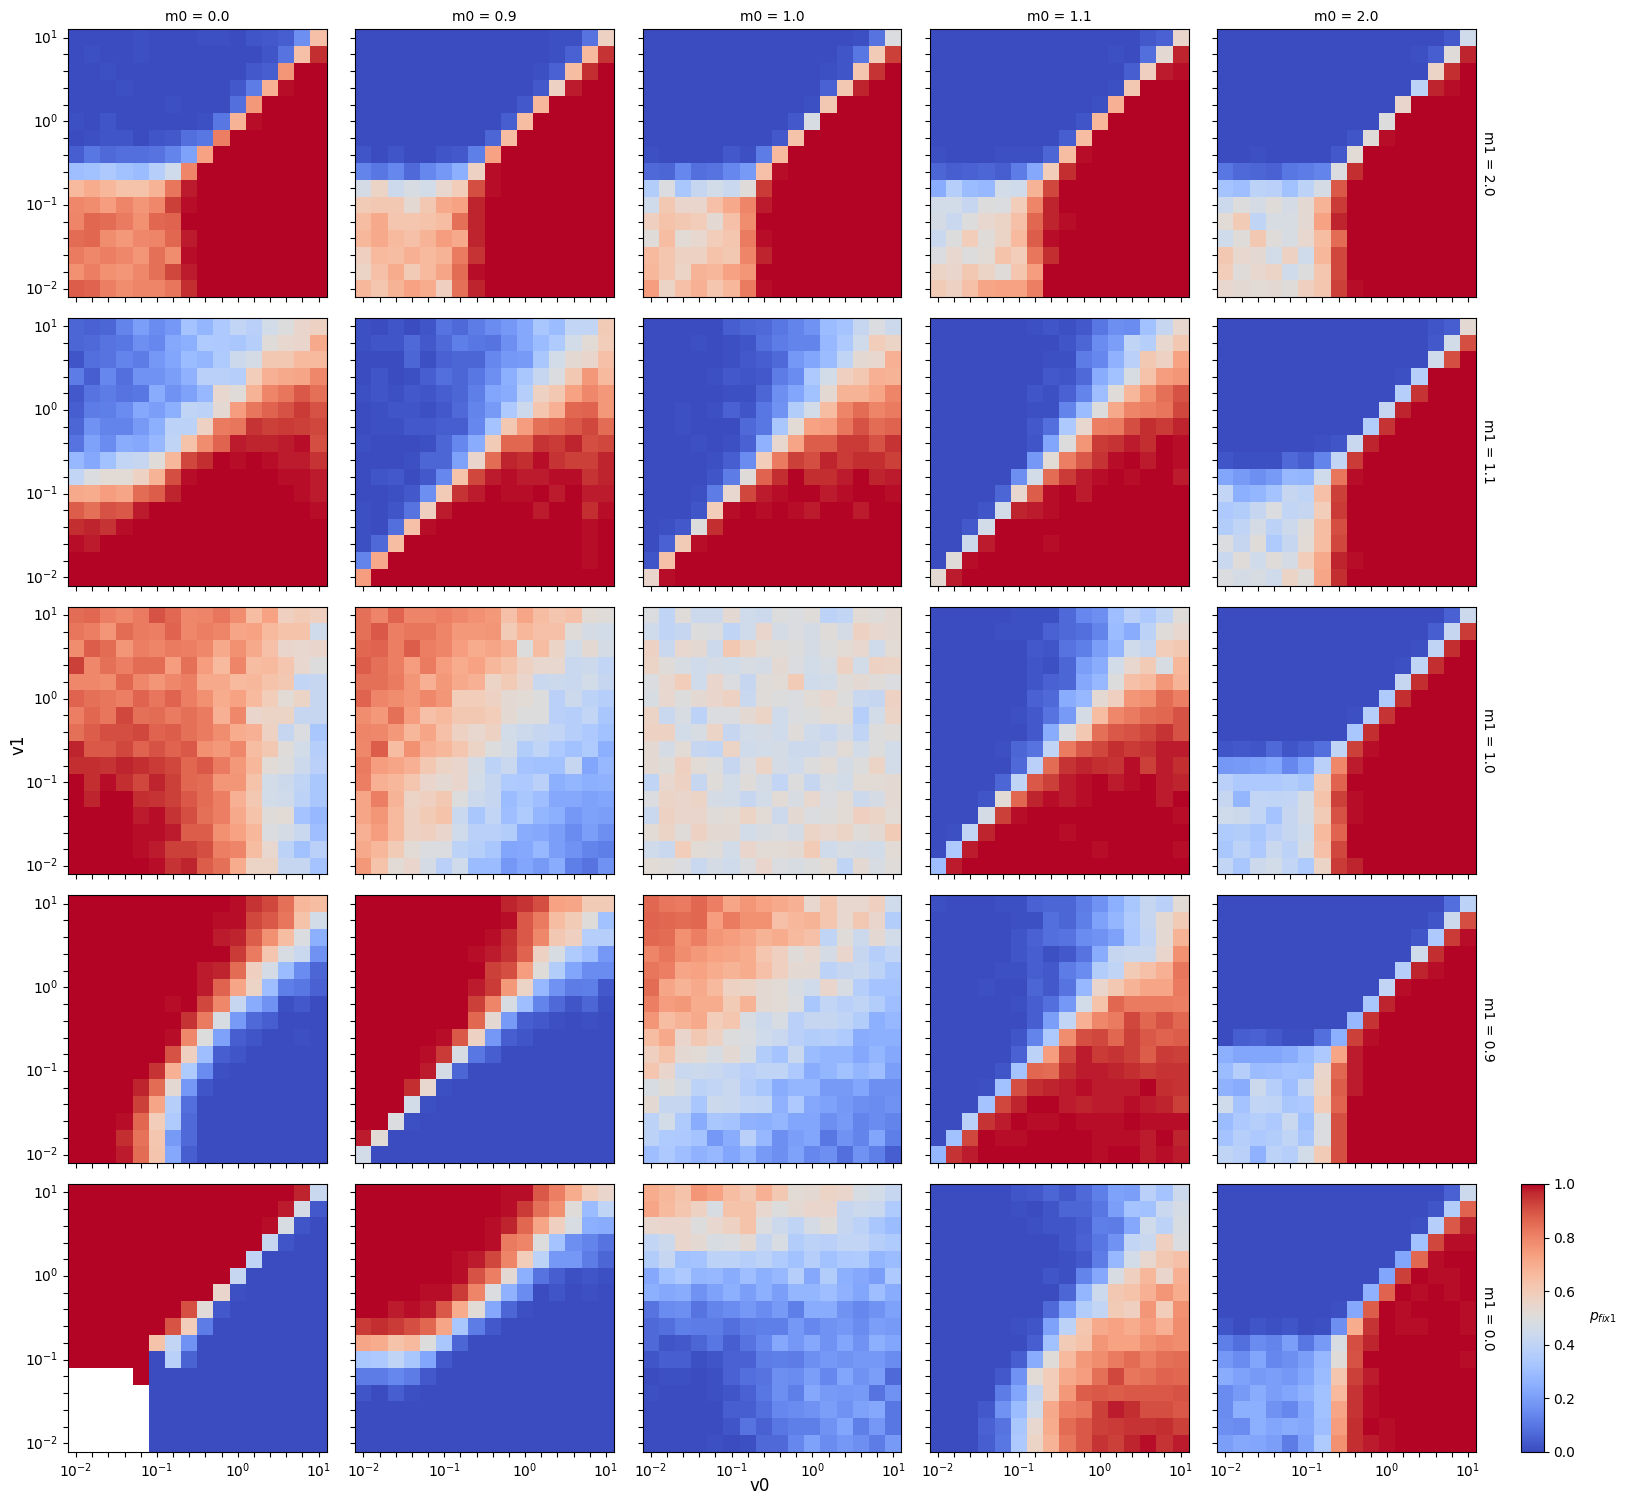

In [110]:
g_1 = plot_facet_heatmap(
    data=d_smr,
    row="m1", col="m0",
    row_order=row_order_m, col_order=col_order_m,
    values="p_fix_l1_1",       # ← change this easily
    cbar_label="$p_{fix1}$"
)

In [58]:
g_0.fig.savefig("L2_n1_step_locus_0_summary.pdf", format="pdf", bbox_inches="tight")
g_1.fig.savefig("L2_n1_step_locus_1_summary.pdf", format="pdf", bbox_inches="tight")

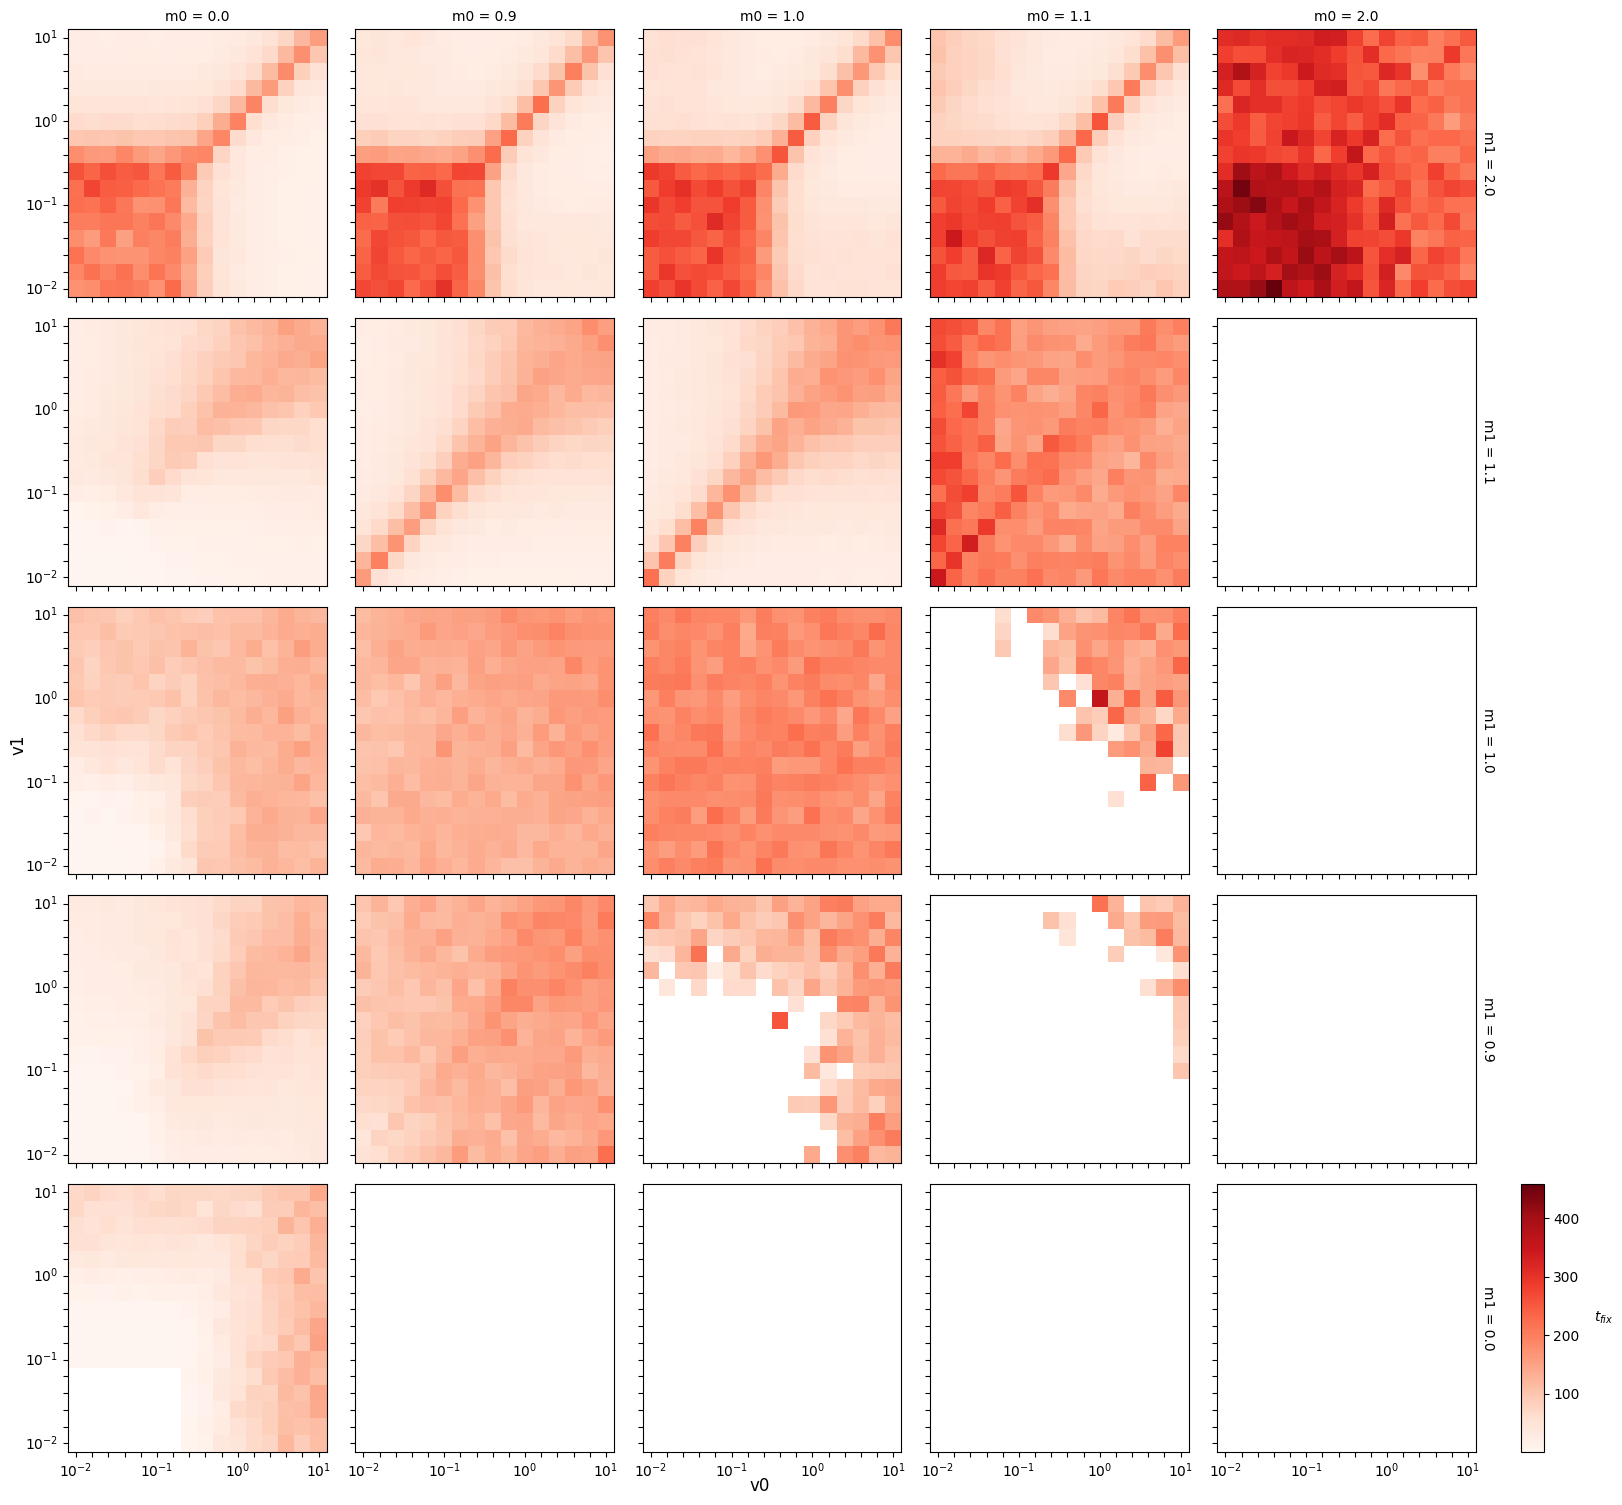

In [111]:
g_t = plot_facet_heatmap(
    data=d_smr,
    row="m1", col="m0",
    row_order=row_order_m, col_order=col_order_m,
    values="t_fix",    
    cmap = "Reds",
    vmin = 1,
    vmax = d_smr["t_fix"].max(),
    cbar_label="$t_{fix}$"
)

In [86]:
g_t.fig.savefig("L2_n1_step_t_fix_summary.pdf", format="pdf", bbox_inches="tight")

Compare with L1_n1

In [87]:
d_L1 = pd.read_csv("data/L1_n1/L1_n1_step.txt", delimiter=" ")

In [90]:
d_L1_gb = d_L1.groupby(["m0", "m1", "v0", "v1"])

In [92]:
d_L1_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean"),
        ).reset_index()

,m0,m1,v0,v1,p_ext,p_fix_1
0,0.0,0.0,0.01,0.010000,1.0,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN
...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,1.00
6396,2.0,2.0,10.00,2.511886,0.0,1.00
6397,2.0,2.0,10.00,3.981072,0.0,1.00
6398,2.0,2.0,10.00,6.309573,0.0,0.94


In [93]:
d_L1_1 = d_L1[d_L1["allele_fixed"] == 1].groupby(["m0", "m1", "v0", "v1"])

In [95]:
d_L1_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

,m0,m1,v0,v1,t_fix_1
0,0.0,0.0,0.01,0.158489,1.000000
1,0.0,0.0,0.01,0.251189,1.214286
2,0.0,0.0,0.01,0.398107,1.869048
3,0.0,0.0,0.01,0.630957,3.020000
4,0.0,0.0,0.01,1.000000,4.430000
...,...,...,...,...,...
3733,2.0,2.0,10.00,1.584893,26.810000
3734,2.0,2.0,10.00,2.511886,40.350000
3735,2.0,2.0,10.00,3.981072,56.220000
3736,2.0,2.0,10.00,6.309573,97.914894


In [98]:
d_L1_smr = pd.merge(
    d_L1_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean"),
        ).reset_index(),
    d_L1_1.agg(t_fix = ("n_gen", "mean")).reset_index(),
    on = ["m0", "m1", "v0", "v1"],
    how = "left"
)

In [99]:
d_L1_smr

,m0,m1,v0,v1,p_ext,p_fix_1,t_fix
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN
...,...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,1.00,26.810000
6396,2.0,2.0,10.00,2.511886,0.0,1.00,40.350000
6397,2.0,2.0,10.00,3.981072,0.0,1.00,56.220000
6398,2.0,2.0,10.00,6.309573,0.0,0.94,97.914894


In [ ]:
d_L1_smr

In [104]:
d_L2_L1_dif = d_L1_smr.merge(d_smr, 
                             on = ["m0", "m1", "v0", "v1"],
                             suffixes=("_L1", "_L2")
                            )

In [106]:
d_L2_L1_dif["t_fix_dif"] = d_L2_L1_dif["t_fix_L2"] - d_L2_L1_dif["t_fix_L1"]

In [107]:
d_L2_L1_dif

,m0,m1,v0,v1,p_ext_L1,p_fix_1,t_fix_L1,p_ext_L2,p_fix_l0_1,p_fix_l1_1,t_fix_L2,log_v0,log_v1,t_fix_dif
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN,1.0,NaN,NaN,NaN,-2.0,-2.0,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN,1.0,NaN,NaN,NaN,-2.0,-1.8,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN,1.0,NaN,NaN,NaN,-2.0,-1.6,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN,1.0,NaN,NaN,NaN,-2.0,-1.4,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN,1.0,NaN,NaN,NaN,-2.0,-1.2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,1.00,26.810000,0.0,0.52,1.00,217.644068,1.0,0.2,190.834068
6396,2.0,2.0,10.00,2.511886,0.0,1.00,40.350000,0.0,0.58,1.00,218.290323,1.0,0.4,177.940323
6397,2.0,2.0,10.00,3.981072,0.0,1.00,56.220000,0.0,0.53,1.00,179.403846,1.0,0.6,123.183846
6398,2.0,2.0,10.00,6.309573,0.0,0.94,97.914894,0.0,0.54,0.97,211.745455,1.0,0.8,113.830561


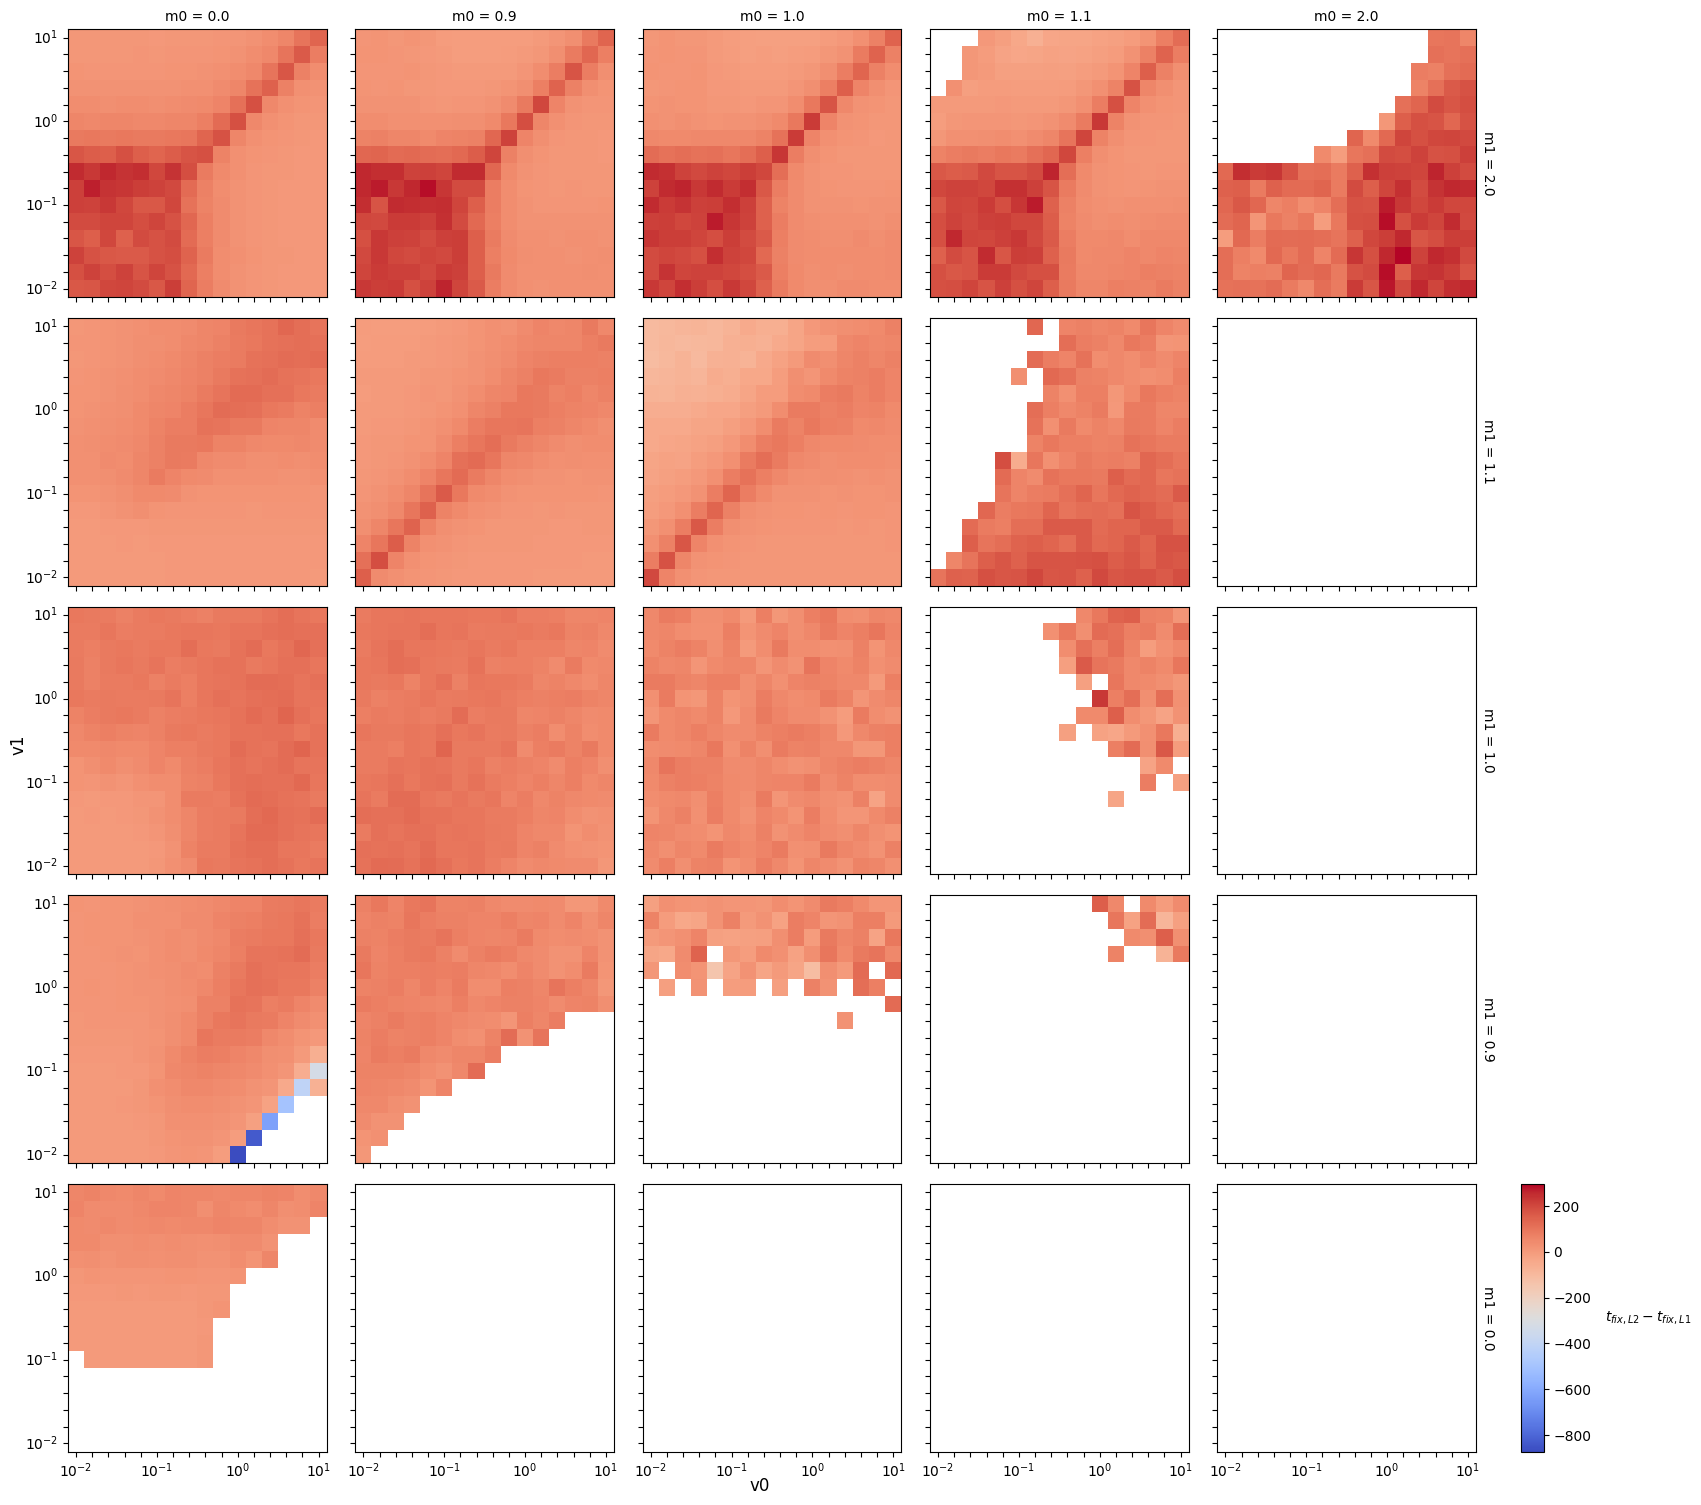

In [109]:
g_t_dif = plot_facet_heatmap(
    data=d_L2_L1_dif,
    row="m1", col="m0",
    row_order=row_order_m, col_order=col_order_m,
    values="t_fix_dif",    
    cmap = "coolwarm",
    vmin = d_L2_L1_dif["t_fix_dif"].min(),
    vmax = d_L2_L1_dif["t_fix_dif"].max(),
    cbar_label="$t_{fix, L2} - t_{fix, L1}$"
)

In [69]:
d_smr

,m0,m1,v0,v1,p_ext,p_fix_l0_1,p_fix_l1_1,t_fix,log_v0,log_v1
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN,NaN,-2.0,-2.0
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN,NaN,-2.0,-1.8
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN,NaN,-2.0,-1.6
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN,NaN,-2.0,-1.4
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN,NaN,-2.0,-1.2
...,...,...,...,...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,0.52,1.00,217.644068,1.0,0.2
6396,2.0,2.0,10.00,2.511886,0.0,0.58,1.00,218.290323,1.0,0.4
6397,2.0,2.0,10.00,3.981072,0.0,0.53,1.00,179.403846,1.0,0.6
6398,2.0,2.0,10.00,6.309573,0.0,0.54,0.97,211.745455,1.0,0.8


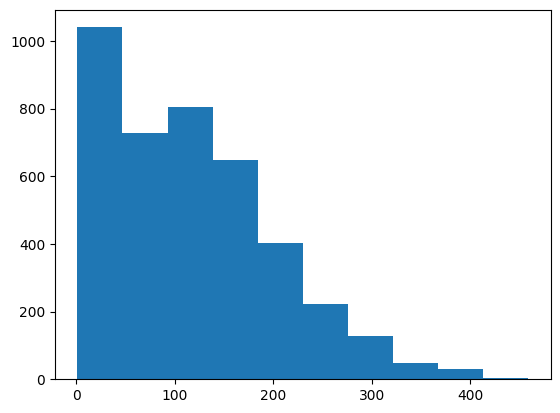

In [70]:
plt.hist(d_smr["t_fix"])
plt.show()

In [60]:
d_smr.head()

,m0,m1,v0,v1,p_ext,p_fix_l0_1,p_fix_l1_1,t_fix,log_v0,log_v1
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN,NaN,-2.0,-2.0
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN,NaN,-2.0,-1.8
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN,NaN,-2.0,-1.6
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN,NaN,-2.0,-1.4
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN,NaN,-2.0,-1.2


In [ ]:
g_t = plot_facet_heatmap(
    data=d_smr,
    row="m1", col="m0",
    row_order=row_order_m, col_order=col_order_m,
    values="t_fix",    
    cmap = "Reds",
    vmin = 1,
    vmax = d_smr["t_fix"].max(),
    cbar_label="$t_{fix}$"
)

In [16]:
g.fig.savefig("L2_n1_step_summary.svg", format="svg", bbox_inches="tight")

In [17]:
g.fig.savefig("L2_n1_step_summary.pdf", format="pdf", bbox_inches="tight")

In [8]:
np.array([1,np.inf]).reshape(1,2,1)

array([[[ 1.],
        [inf]]])

In [13]:
z = np.linspace(-4,5,101).reshape((101,1))

In [14]:
w = hanoi.fit_step(z = z, boxes = np.array([1, np.inf]).reshape((1,2,1)))

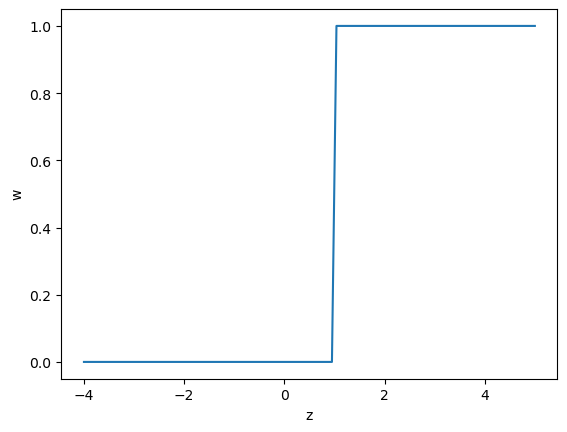

In [18]:
plt.plot(z, w)
plt.xlabel("z")
plt.ylabel("w")
plt.savefig("L1_n1_step_fitness_funcs.pdf", bbox_inches="tight")
plt.show()